# Исследовательский анализ данных

В ноутбуке рассматриваются четыре исходные таблицы проекта:

- `users.tsv` содержит характеристики пользователей;
- `history.tsv` содержит историю рекламных показов;
- `validate.tsv` описывает рекламные кампании;
- `validate_answers.tsv` содержит доли пользователей, получивших не менее одного, двух и трех показов.

Цель анализа: проверить качество данных, изучить распределения и найти связи, которые могут быть полезны при построении модели.


## 1. Импорты и загрузка данных


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

users = pd.read_csv(ROOT / "users.tsv", sep="\t")
history = pd.read_csv(ROOT / "history.tsv", sep="\t")
campaigns = pd.read_csv(ROOT / "validate.tsv", sep="\t")
answers = pd.read_csv(ROOT / "validate_answers.tsv", sep="\t")

TARGETS = ["at_least_one", "at_least_two", "at_least_three"]


## 2. Структура и качество данных


In [2]:
tables = {
    "users": users,
    "history": history,
    "campaigns": campaigns,
    "answers": answers,
}

summary = pd.DataFrame({
    "rows": {name: len(df) for name, df in tables.items()},
    "columns": {name: df.shape[1] for name, df in tables.items()},
    "missing_values": {name: int(df.isna().sum().sum()) for name, df in tables.items()},
    "duplicate_rows": {name: int(df.duplicated().sum()) for name, df in tables.items()},
})
display(summary)

for name, df in tables.items():
    print(f"\n{name}:")
    display(df.head(3))


,rows,columns,missing_values,duplicate_rows
users,27769,4,0,0
history,1147857,4,0,22190
campaigns,1008,6,0,0
answers,1008,3,0,130



users:


,user_id,sex,age,city_id
0,0,2,19,0
1,1,1,0,1
2,2,2,24,2



history:


,hour,cpm,publisher,user_id
0,10,30.00,1,15661
1,8,41.26,1,8444
2,7,360.00,1,15821



campaigns:


,cpm,hour_start,hour_end,publishers,audience_size,user_ids
0,220.0,1058,1153,"7,17",1906,"12,44,46,50,58,71,93,122,134,143,176,184,187,1..."
1,312.0,1295,1301,"3,18",1380,"29,81,98,102,165,167,195,205,218,231,242,263,3..."
2,70.0,1229,1249,"1,2,3,9,15,21",888,"12,23,25,29,45,85,92,124,156,190,272,334,456,5..."



answers:


,at_least_one,at_least_two,at_least_three
0,0.0430,0.0152,0.0073
1,0.0130,0.0000,0.0000
2,0.0878,0.0135,0.0000


Отсутствие пропусков не означает, что все значения заполнены содержательно. Например, нулевые значения возраста, пола или города могут обозначать неизвестную категорию, поэтому их доли проверяются отдельно.


In [3]:
unknown_values = pd.Series({
    "sex = 0": (users["sex"] == 0).mean(),
    "age = 0": (users["age"] == 0).mean(),
    "city_id = 0": (users["city_id"] == 0).mean(),
}, name="share").to_frame()
unknown_values["share_percent"] = (unknown_values["share"] * 100).round(2)
display(unknown_values)


,share,share_percent
sex = 0,0.001080,0.11
age = 0,0.078505,7.85
city_id = 0,0.305340,30.53


## 3. Пользователи


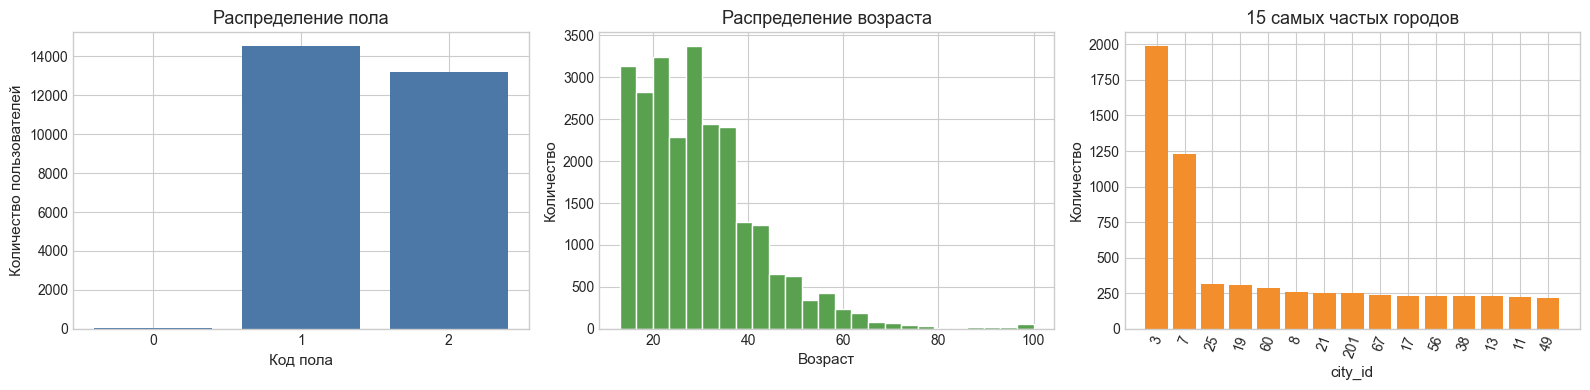

,sex,age,city_id
count,27769.00,27769.00,27769.00
mean,1.48,28.89,240.14
std,0.50,18.51,466.12
min,0.00,0.00,0.00
25%,1.00,18.00,0.00
50%,1.00,27.00,25.00
75%,2.00,36.00,231.00
max,2.00,118.00,2456.00


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sex_counts = users["sex"].value_counts().sort_index()
axes[0].bar(sex_counts.index.astype(str), sex_counts.values, color="#4C78A8")
axes[0].set(title="Распределение пола", xlabel="Код пола", ylabel="Количество пользователей")

known_age = users.loc[users["age"].between(1, 100), "age"]
axes[1].hist(known_age, bins=25, color="#59A14F", edgecolor="white")
axes[1].set(title="Распределение возраста", xlabel="Возраст", ylabel="Количество")

city_counts = users.loc[users["city_id"] != 0, "city_id"].value_counts().head(15)
axes[2].bar(city_counts.index.astype(str), city_counts.values, color="#F28E2B")
axes[2].tick_params(axis="x", rotation=70)
axes[2].set(title="15 самых частых городов", xlabel="city_id", ylabel="Количество")

plt.tight_layout()
plt.show()

display(users[["sex", "age", "city_id"]].describe().round(2))


Графики показывают состав аудитории. Возраст анализируется без кодов `0` и значений выше 100, чтобы служебные или аномальные значения не искажали форму распределения. Для городов важна не величина `city_id`, а частота каждой категории.


## 4. История показов


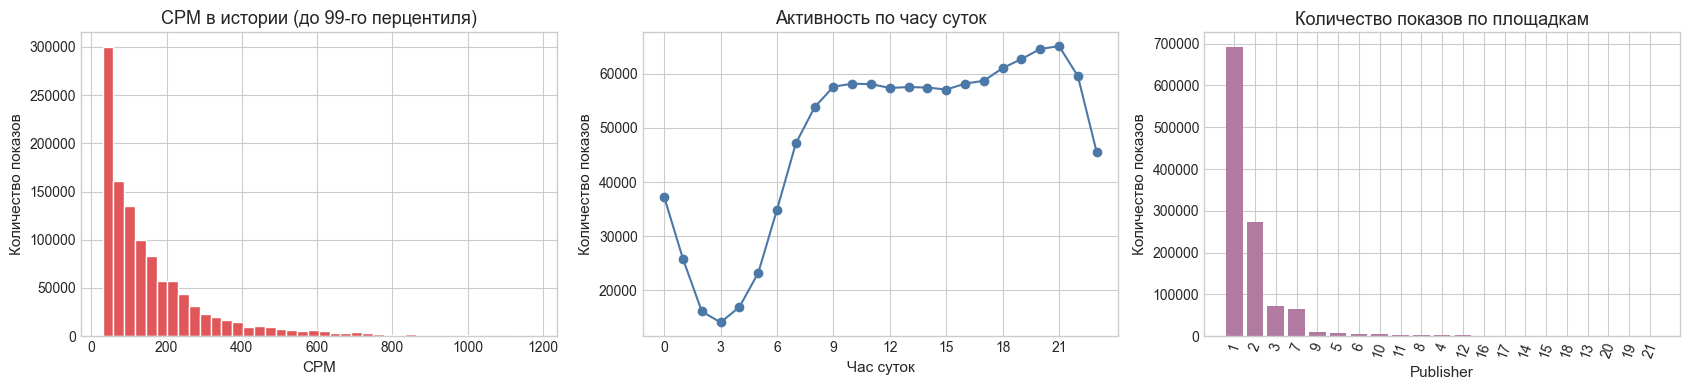

,hour,cpm,publisher,user_id
count,1147857.00,1147857.00,1147857.00,1147857.00
mean,760.30,186.40,2.00,13847.39
std,430.62,455.73,2.06,8028.62
min,3.00,30.00,1.00,0.00
25%,392.00,55.00,1.00,6817.00
50%,762.00,110.00,1.00,13941.00
75%,1138.00,210.00,2.00,20759.00
max,1490.00,209053.98,21.00,27768.00


In [5]:
history_analysis = history.assign(
    hour_of_day=history["hour"] % 24,
    day=history["hour"] // 24,
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

cpm_limit = history["cpm"].quantile(0.99)
axes[0].hist(
    history.loc[history["cpm"] <= cpm_limit, "cpm"],
    bins=40,
    color="#E15759",
    edgecolor="white",
)
axes[0].set(
    title="CPM в истории (до 99-го перцентиля)",
    xlabel="CPM",
    ylabel="Количество показов",
)

hourly_activity = history_analysis.groupby("hour_of_day").size()
axes[1].plot(hourly_activity.index, hourly_activity.values, marker="o", color="#4C78A8")
axes[1].set(
    title="Активность по часу суток",
    xlabel="Час суток",
    ylabel="Количество показов",
    xticks=range(0, 24, 3),
)

publisher_counts = history["publisher"].value_counts().sort_values(ascending=False)
axes[2].bar(publisher_counts.index.astype(str), publisher_counts.values, color="#B07AA1")
axes[2].tick_params(axis="x", rotation=70)
axes[2].set(
    title="Количество показов по площадкам",
    xlabel="Publisher",
    ylabel="Количество показов",
)

plt.tight_layout()
plt.show()

display(history[["hour", "cpm", "publisher", "user_id"]].describe().round(2))


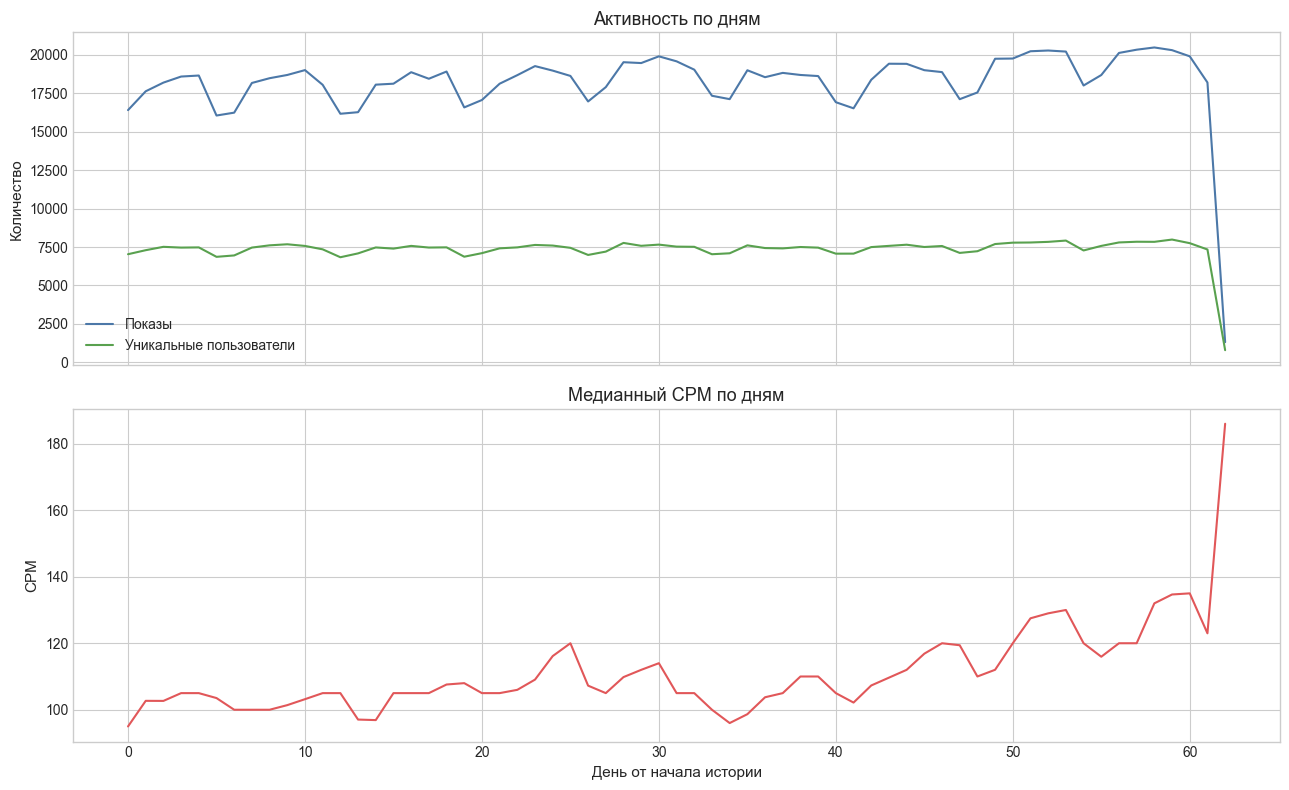

In [6]:
daily = history_analysis.groupby("day").agg(
    impressions=("user_id", "size"),
    unique_users=("user_id", "nunique"),
    median_cpm=("cpm", "median"),
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(daily.index, daily["impressions"], label="Показы", color="#4C78A8")
axes[0].plot(daily.index, daily["unique_users"], label="Уникальные пользователи", color="#59A14F")
axes[0].set(title="Активность по дням", ylabel="Количество")
axes[0].legend()

axes[1].plot(daily.index, daily["median_cpm"], color="#E15759")
axes[1].set(title="Медианный CPM по дням", xlabel="День от начала истории", ylabel="CPM")

plt.tight_layout()
plt.show()


Временные графики позволяют обнаружить суточную сезонность, изменение объема трафика и сдвиги уровня ставок. Такие закономерности важны, потому что тестовый период расположен позже доступной истории.


## 5. Кампании


In [7]:
def parse_ids(value):
    return [int(item) for item in str(value).split(",") if item]


campaign_analysis = campaigns.copy()
campaign_analysis["window_length"] = campaign_analysis["hour_end"] - campaign_analysis["hour_start"]
campaign_analysis["publisher_list"] = campaign_analysis["publishers"].map(parse_ids)
campaign_analysis["publisher_count"] = campaign_analysis["publisher_list"].map(len)
campaign_analysis["user_list"] = campaign_analysis["user_ids"].map(parse_ids)
campaign_analysis["listed_users"] = campaign_analysis["user_list"].map(len)
campaign_analysis["start_hour_of_day"] = campaign_analysis["hour_start"] % 24

quality_checks = pd.Series({
    "Кампаний": len(campaign_analysis),
    "Несовпадений audience_size и числа user_id": (
        campaign_analysis["audience_size"] != campaign_analysis["listed_users"]
    ).sum(),
    "Кампаний с неположительной длиной окна": (
        campaign_analysis["window_length"] <= 0
    ).sum(),
})
display(quality_checks.to_frame("value"))


,value
Кампаний,1008
Несовпадений audience_size и числа user_id,0
Кампаний с неположительной длиной окна,0


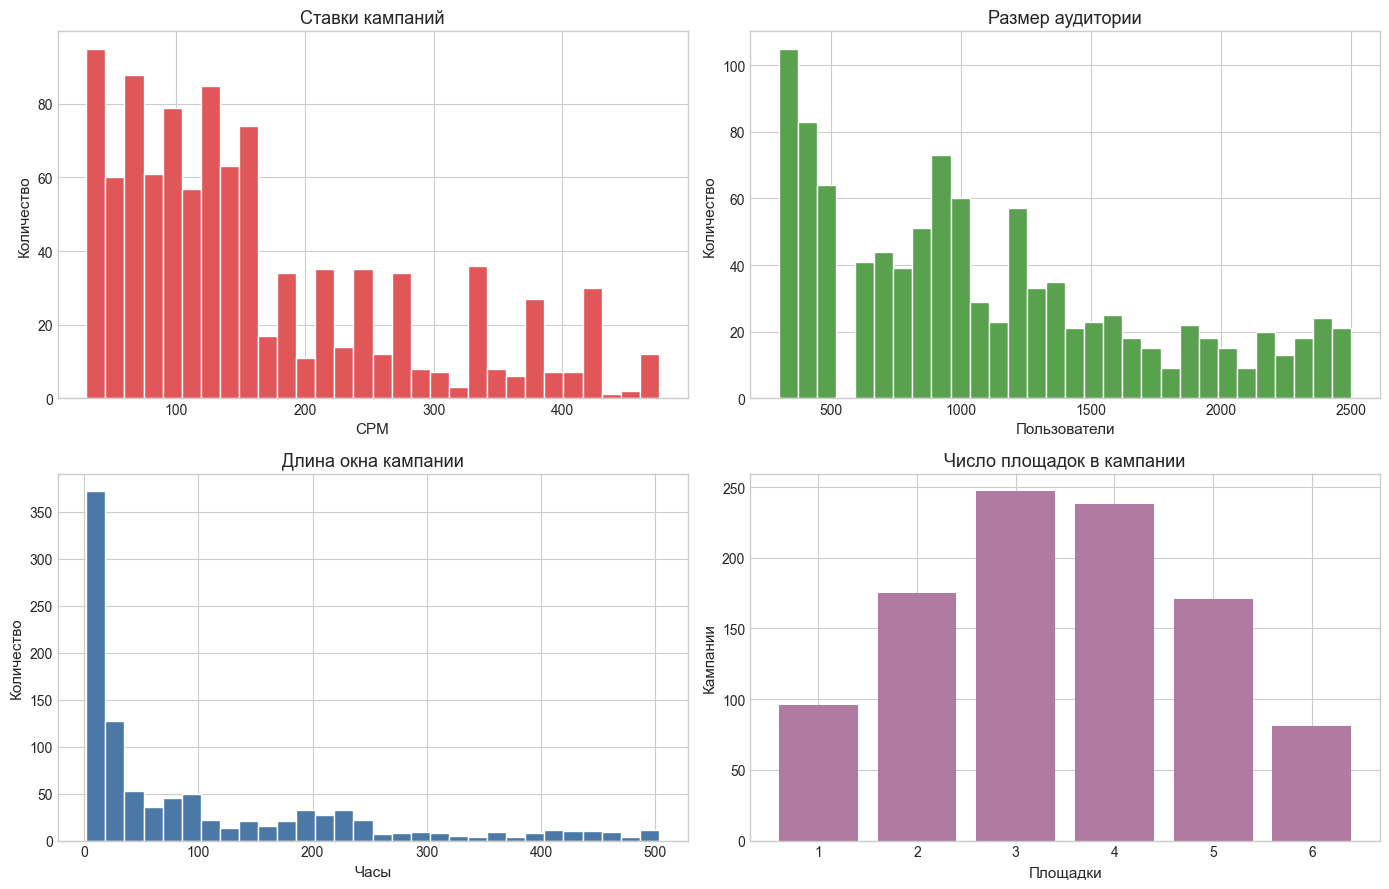

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(campaign_analysis["cpm"], bins=30, color="#E15759", edgecolor="white")
axes[0, 0].set(title="Ставки кампаний", xlabel="CPM", ylabel="Количество")

axes[0, 1].hist(campaign_analysis["audience_size"], bins=30, color="#59A14F", edgecolor="white")
axes[0, 1].set(title="Размер аудитории", xlabel="Пользователи", ylabel="Количество")

axes[1, 0].hist(campaign_analysis["window_length"], bins=30, color="#4C78A8", edgecolor="white")
axes[1, 0].set(title="Длина окна кампании", xlabel="Часы", ylabel="Количество")

publisher_count_frequency = campaign_analysis["publisher_count"].value_counts().sort_index()
axes[1, 1].bar(
    publisher_count_frequency.index.astype(str),
    publisher_count_frequency.values,
    color="#B07AA1",
)
axes[1, 1].set(title="Число площадок в кампании", xlabel="Площадки", ylabel="Кампании")

plt.tight_layout()
plt.show()


## 6. Целевые переменные


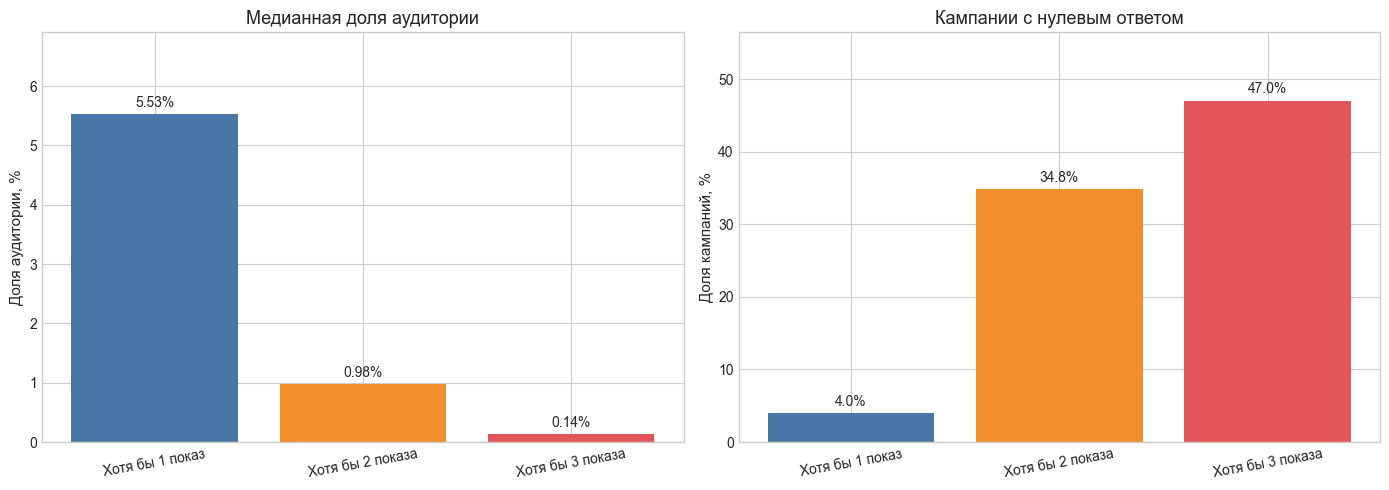

,at_least_one,at_least_two,at_least_three
count,1008.0000,1008.0000,1008.0000
mean,0.1154,0.0658,0.0472
std,0.1461,0.1178,0.0990
min,0.0000,0.0000,0.0000
25%,0.0166,0.0000,0.0000
50%,0.0552,0.0098,0.0014
75%,0.1587,0.0781,0.0490
max,0.9307,0.9097,0.8834


,violations
at_least_two > at_least_one,0
at_least_three > at_least_two,0
"значения вне [0, 1]",0


In [9]:
target_labels = ["Хотя бы 1 показ", "Хотя бы 2 показа", "Хотя бы 3 показа"]
colors = ["#4C78A8", "#F28E2B", "#E15759"]
median_percent = answers[TARGETS].median().to_numpy() * 100
zero_share_percent = answers[TARGETS].eq(0).mean().to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(target_labels, median_percent, color=colors)
axes[0].bar_label(bars, fmt="%.2f%%", padding=3)
axes[0].set(
    title="Медианная доля аудитории",
    ylabel="Доля аудитории, %",
)
axes[0].set_ylim(0, max(median_percent) * 1.25)

bars = axes[1].bar(target_labels, zero_share_percent, color=colors)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].set(
    title="Кампании с нулевым ответом",
    ylabel="Доля кампаний, %",
)
axes[1].set_ylim(0, max(zero_share_percent) * 1.2)

for axis in axes:
    axis.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

target_checks = pd.Series({
    "at_least_two > at_least_one": (answers["at_least_two"] > answers["at_least_one"]).sum(),
    "at_least_three > at_least_two": (answers["at_least_three"] > answers["at_least_two"]).sum(),
    "значения вне [0, 1]": ((answers[TARGETS] < 0) | (answers[TARGETS] > 1)).sum().sum(),
})
display(answers.describe().round(4))
display(target_checks.to_frame("violations"))


Таргеты должны быть упорядочены: доля пользователей с тремя показами не может превышать долю с двумя, а доля с двумя не может превышать долю с одним. Проверка также подтверждает, что значения являются долями от 0 до 1.


## 7. Связи признаков кампании с результатом


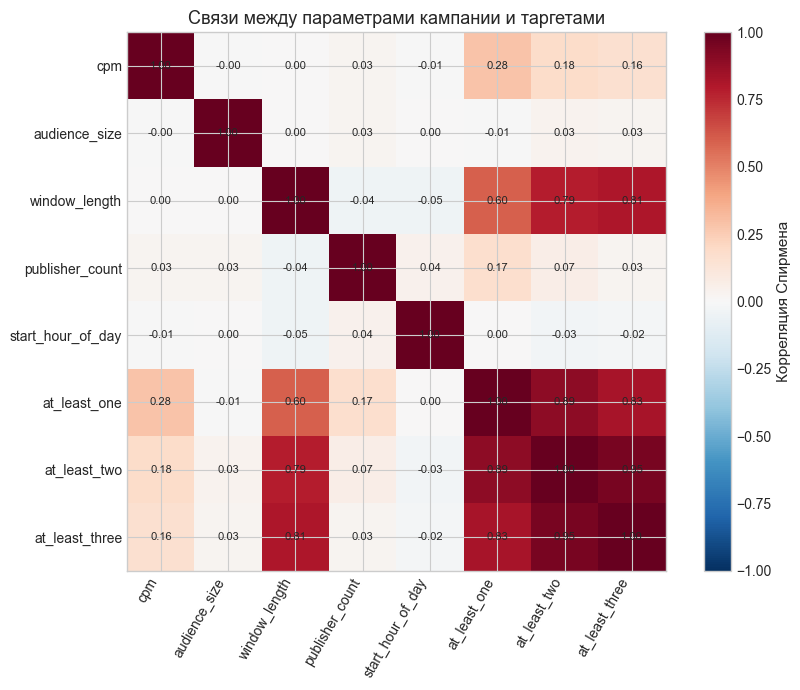

In [10]:
analysis = pd.concat(
    [
        campaign_analysis[[
            "cpm",
            "audience_size",
            "window_length",
            "publisher_count",
            "start_hour_of_day",
        ]],
        answers,
    ],
    axis=1,
)

corr = analysis.corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Корреляция Спирмена")
ax.set_title("Связи между параметрами кампании и таргетами")
plt.tight_layout()
plt.show()


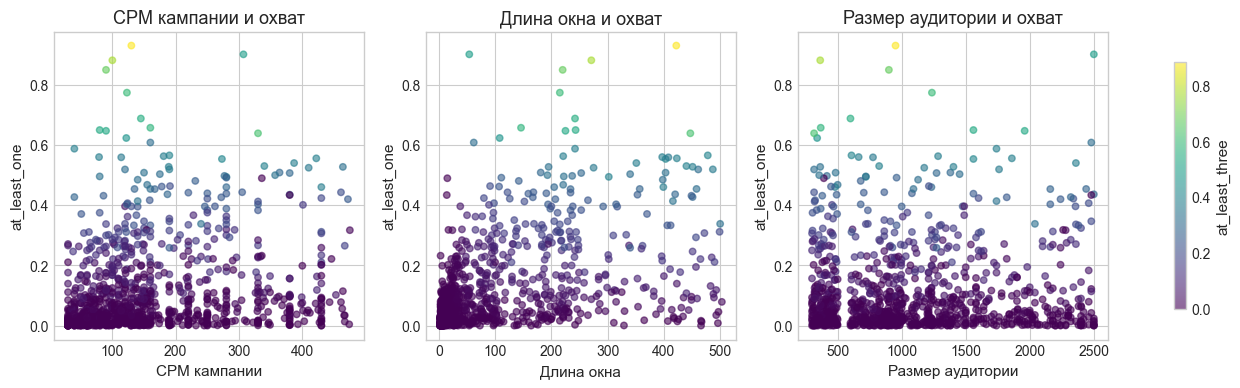

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
features_to_plot = [
    ("cpm", "CPM кампании"),
    ("window_length", "Длина окна"),
    ("audience_size", "Размер аудитории"),
]

for ax, (feature, label) in zip(axes, features_to_plot):
    points = ax.scatter(
        analysis[feature],
        analysis["at_least_one"],
        c=analysis["at_least_three"],
        cmap="viridis",
        alpha=0.6,
        s=22,
    )
    ax.set(title=f"{label} и охват", xlabel=label, ylabel="at_least_one")

fig.colorbar(points, ax=axes, label="at_least_three", shrink=0.8)
plt.show()


Корреляция показывает направление монотонной связи, но не доказывает причинность. Диаграммы рассеяния дополнительно показывают нелинейность, выбросы и разброс результатов при одинаковых параметрах кампании.


## 8. Взаимодействие кампаний с историей


In [12]:
publisher_stats = history.groupby("publisher")["cpm"].agg(
    history_cpm_median="median",
    history_cpm_p90=lambda values: values.quantile(0.90),
)

def mean_publisher_stat(publishers, column):
    values = publisher_stats.reindex(publishers)[column]
    return values.mean()


campaign_analysis["publisher_cpm_median"] = campaign_analysis["publisher_list"].map(
    lambda values: mean_publisher_stat(values, "history_cpm_median")
)
campaign_analysis["publisher_cpm_p90"] = campaign_analysis["publisher_list"].map(
    lambda values: mean_publisher_stat(values, "history_cpm_p90")
)
campaign_analysis["cpm_to_publisher_p90"] = (
    campaign_analysis["cpm"] / campaign_analysis["publisher_cpm_p90"]
)

user_history = history.groupby("user_id").agg(
    previous_impressions=("hour", "size"),
    previous_active_hours=("hour", "nunique"),
)

def audience_mean(user_ids, column):
    return user_history.reindex(user_ids)[column].fillna(0).mean()


campaign_analysis["audience_previous_impressions"] = campaign_analysis["user_list"].map(
    lambda values: audience_mean(values, "previous_impressions")
)
campaign_analysis["audience_previous_active_hours"] = campaign_analysis["user_list"].map(
    lambda values: audience_mean(values, "previous_active_hours")
)

history_interaction = pd.concat(
    [
        campaign_analysis[[
            "cpm_to_publisher_p90",
            "audience_previous_impressions",
            "audience_previous_active_hours",
        ]],
        answers,
    ],
    axis=1,
)
display(history_interaction.corr(method="spearman").round(3))


,cpm_to_publisher_p90,audience_previous_impressions,audience_previous_active_hours,at_least_one,at_least_two,at_least_three
cpm_to_publisher_p90,1.000,0.003,-0.001,0.272,0.169,0.142
audience_previous_impressions,0.003,1.000,0.994,0.334,0.231,0.209
audience_previous_active_hours,-0.001,0.994,1.000,0.338,0.231,0.210
at_least_one,0.272,0.334,0.338,1.000,0.892,0.827
at_least_two,0.169,0.231,0.231,0.892,1.000,0.951
at_least_three,0.142,0.209,0.210,0.827,0.951,1.000


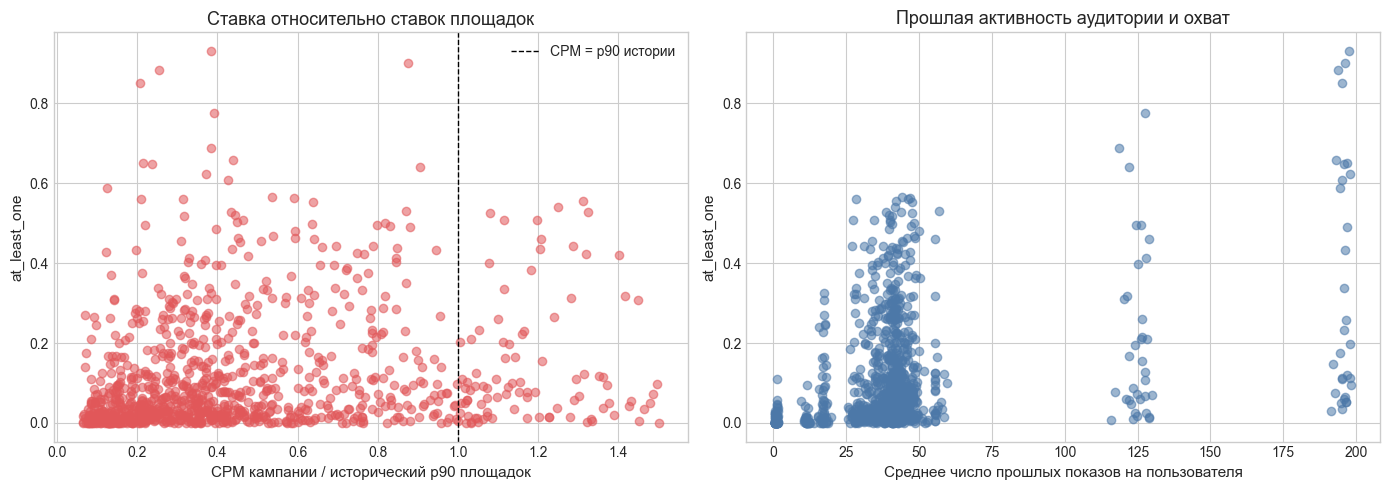

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    history_interaction["cpm_to_publisher_p90"],
    history_interaction["at_least_one"],
    alpha=0.55,
    color="#E15759",
)
axes[0].axvline(1, color="black", linestyle="--", linewidth=1, label="CPM = p90 истории")
axes[0].set(
    title="Ставка относительно ставок площадок",
    xlabel="CPM кампании / исторический p90 площадок",
    ylabel="at_least_one",
)
axes[0].legend()

axes[1].scatter(
    history_interaction["audience_previous_impressions"],
    history_interaction["at_least_one"],
    alpha=0.55,
    color="#4C78A8",
)
axes[1].set(
    title="Прошлая активность аудитории и охват",
    xlabel="Среднее число прошлых показов на пользователя",
    ylabel="at_least_one",
)

plt.tight_layout()
plt.show()


Отношение ставки кампании к 90-му перцентилю исторического CPM описывает конкурентоспособность ставки на выбранных площадках. Активность аудитории в истории показывает, насколько часто выбранные пользователи вообще встречались в рекламном трафике. Эти признаки объединяют несколько исходных таблиц и могут быть полезнее изолированных параметров кампании.


## 9. Основные наблюдения


In [14]:
target_correlations = corr.loc[
    ["cpm", "audience_size", "window_length", "publisher_count", "start_hour_of_day"],
    "at_least_one",
].abs().sort_values(ascending=False)

interaction_correlations = history_interaction.corr(method="spearman")[
    "at_least_one"
].drop("at_least_one").abs().sort_values(ascending=False)

print("Самые заметные связи с at_least_one среди параметров кампании:")
display(target_correlations.to_frame("absolute_spearman"))

print("Связи признаков, построенных по истории, с at_least_one:")
display(interaction_correlations.to_frame("absolute_spearman"))


Самые заметные связи с at_least_one среди параметров кампании:


,absolute_spearman
window_length,0.596056
cpm,0.281615
publisher_count,0.165704
audience_size,0.007241
start_hour_of_day,0.001547


Связи признаков, построенных по истории, с at_least_one:


,absolute_spearman
at_least_two,0.892494
at_least_three,0.826764
audience_previous_active_hours,0.338218
audience_previous_impressions,0.333911
cpm_to_publisher_p90,0.272060


По результатам анализа можно определить:

- есть ли в таблицах пропуски, дубликаты и некорректные значения;
- насколько неоднородны пользователи, площадки и рекламные ставки;
- присутствуют ли временная сезонность и изменения трафика;
- как распределены параметры кампаний и целевые значения;
- какие параметры кампании сильнее связаны с охватом;
- какую дополнительную информацию дает объединение кампаний с историей показов.

Следующий этап после EDA: использовать найденные зависимости для отбора признаков и сравнить модели на временном разбиении.
